### **Electricity Consumption Forecasting**



In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "robikscube/hourly-energy-consumption"
)
print("Dataset downloaded at:", path)

100%|██████████| 11.4M/11.4M [00:00<00:00, 86.5MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3


In [10]:
import os
print(os.listdir(path))

['est_hourly.paruqet', 'COMED_hourly.csv', 'PJMW_hourly.csv', 'NI_hourly.csv', 'PJM_Load_hourly.csv', 'FE_hourly.csv', 'pjm_hourly_est.csv', 'AEP_hourly.csv', 'EKPC_hourly.csv', 'DOM_hourly.csv', 'DEOK_hourly.csv', 'PJME_hourly.csv', 'DUQ_hourly.csv', 'DAYTON_hourly.csv']


In [11]:
import pandas as pd

file_path = path + "/PJME_hourly.csv"
df = pd.read_csv(file_path)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [12]:
#Cconversion to datetime, sorting
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


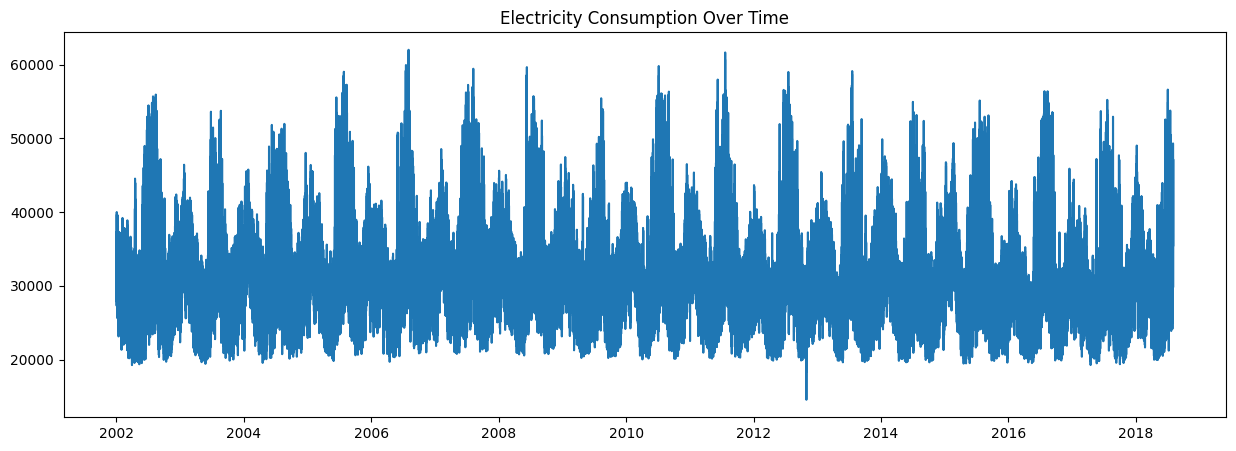

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['PJME_MW'])
plt.title("Electricity Consumption Over Time")
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data = scaler.fit_transform(df[['PJME_MW']])

In [15]:
import numpy as np

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(data, time_step)

In [16]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [17]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)

(116244, 60, 1)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()

model.add(SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 72s 36ms/step - loss: 0.0018 - val_loss: 1.3324e-04
Epoch 2/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 73s 31ms/step - loss: 1.2985e-04 - val_loss: 1.1232e-04
Epoch 3/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 96s 39ms/step - loss: 8.6880e-05 - val_loss: 7.6935e-05
Epoch 4/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 62s 34ms/step - loss: 7.6543e-05 - val_loss: 5.0106e-05
Epoch 5/5
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 57s 32ms/step - loss: 7.3730e-05 - val_loss: 6.1136e-05


In [20]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

909/909 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step


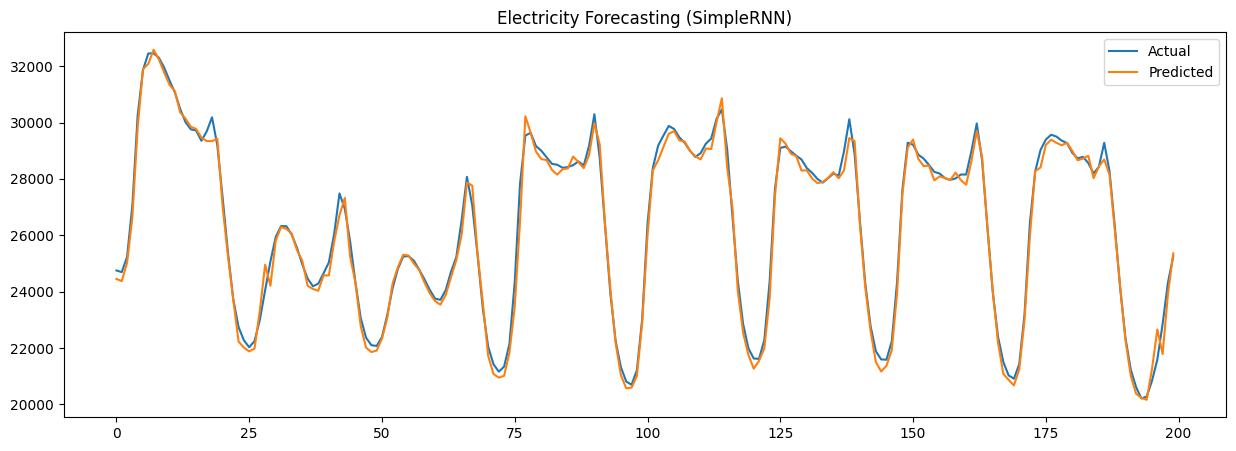

In [21]:
plt.figure(figsize=(15,5))
plt.plot(y_test_actual[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.title("Electricity Forecasting (SimpleRNN)")
plt.show()

In [22]:
last_60 = data[-60:]
input_seq = last_60.reshape(1, 60, 1)

future = []
for i in range(24):
    pred = model.predict(input_seq)[0][0]
    future.append(pred)
    input_seq = np.append(input_seq[:,1:,:], [[[pred]]], axis=1)
future = scaler.inverse_transform(np.array(future).reshape(-1,1))
print(future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[32785.77 ]
 [30229.035]
 [27914.984]
 [26157.67 ]
 [25014.865]
 [24716.455]
 [25009.79

In [23]:
model.save("electricity_rnn_model.keras")

In [24]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [25]:
from google.colab import files

files.download("electricity_rnn_model.keras")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
files.download(path+"/PJME_hourly.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>